# Fractal — Quick-Start Workshop

Sections:

1. **Setup** — how to install
2. **Hello Fractal** — passive lender, end-to-end in ~30 lines
3. **Entity as a model** — drive a `UniswapV2LPEntity` by hand, plot
   portfolio value vs. price across an IL scenario
4. **Real-data backtest** — ETH/USDC V2 pool, "deposit and hold" baseline
5. **Where to go next** — grid search + MLflow live demo

## 1. Setup & imports


In [ ]:
!pip install fractal-defi & pip install matplotlib

In [7]:
from fractal.core.base import (
    Action, ActionToTake,
    BaseStrategy, BaseStrategyParams,
    NamedEntity, Observation,
)
from fractal.core.entities import (
    SimpleLendingEntity, SimpleLendingGlobalState,
    UniswapV2LPConfig, UniswapV2LPEntity, UniswapV2LPGlobalState,
)

## 2. Hello Fractal — passive lender

The smallest end-to-end Fractal example. We deposit \$10,000 of USDC into
a lending market that pays a flat 5% APY, watch it compound hourly for a
year, and confirm it matches the closed-form `P · (1 + r/n)^n`.

Three Fractal primitives at play:

- **`Entity`** — a typed state machine. `SimpleLendingEntity` here.
- **`Strategy`** — owns a set of named entities and decides what to do
  on each tick via `predict()`.
- **`Observation`** — a `(timestamp, {entity_name: GlobalState})` tuple
  the framework hands the strategy on every step. Drives entity
  `update_state` (interest accrual) and the strategy's `predict` loop.


In [9]:
SimpleLendingEntity().get_available_actions()

['borrow', 'deposit', 'repay', 'withdraw']

In [10]:
from dataclasses import dataclass
from datetime import UTC, datetime, timedelta
from typing import List


@dataclass
class LendingParams(BaseStrategyParams):
    INITIAL_BALANCE: float = 10_000.0
    LENDING_APY: float = 0.05


class PassiveLenderStrategy(BaseStrategy[LendingParams]):
    """Deposit once, then sit and accrue."""

    def set_up(self) -> None:
        self.register_entity(NamedEntity(
            entity_name="LENDING",
            entity=SimpleLendingEntity(),
        ))
        self._funded: bool = False

    def predict(self) -> List[ActionToTake]:
        if self._funded:
            return []
        self._funded = True
        return [
            ActionToTake(
            "LENDING", Action("deposit", {"amount_in_notional": self._params.INITIAL_BALANCE},
        ))]

**Synthetic observations** — one year of hourly snapshots with a
constant lending rate. No loader, no network — the framework will
call `update_state` on every observation and the entity compounds.


In [11]:
def build_observations(apy: float, days: int = 365) -> List[Observation]:
    hours = days * 24
    per_step = apy / hours
    start = datetime(2024, 1, 1, tzinfo=UTC)
    return [
        Observation(timestamp=start + timedelta(hours=i), states={
            "LENDING": SimpleLendingGlobalState(
                collateral_price=1.0, debt_price=1.0,
                lending_rate=per_step, borrowing_rate=0.0,
            ),
        })
        for i in range(hours + 1)
    ]


params = LendingParams()
observations = build_observations(apy=params.LENDING_APY)
print(f"observations: {len(observations)} (1 year @ {params.LENDING_APY:.0%} APY)")

observations: 8761 (1 year @ 5% APY)


In [12]:
strategy = PassiveLenderStrategy(params=params)
result = strategy.run(observations)
result.get_default_metrics()

StrategyMetrics(accumulated_return=np.float64(0.05127094636609697), apy=np.float64(0.05127094636609697), sharpe=0.0, max_drawdown=0.0)

In [13]:
df = result.to_dataframe()
final = float(df["net_balance"].iloc[-1])
closed = params.INITIAL_BALANCE * (1 + params.LENDING_APY / (365 * 24)) ** (365 * 24)
print(f"final balance:  {final:,.4f}")
print(f"closed-form:    {closed:,.4f}")
print(f"mismatch:       {abs(final - closed):.3e}")

final balance:  10,512.7095
closed-form:    10,512.7095
mismatch:       7.640e-11


## 3. Entity as a model — UniswapV2 LP

A Fractal entity is just a typed state machine. You can construct one,
call its `action_*` and `update_state` methods directly, and inspect
its `internal_state` after each step — no Strategy required. That's
useful for **building intuition** about the protocol mechanics.

We'll set up an ETH/USDC LP position at price $3,000 with $10,000
deposited, then drive the price up to $5,000 and back down to $1,500
in a synthetic walk, and plot:

- **LP position value** at each step (what the entity reports)
- **HODL value** — what you'd have if you'd kept the same dollar value
  in 50% USDC + 50% ETH at the entry price

The gap between them is **impermanent loss** (IL).


In [14]:
import numpy as np

# 0.30% pool (the original V2 USDC/WETH pool fee tier).
config = UniswapV2LPConfig(
    pool_fee_rate=0.003,
    notional_side="token0",  # USDC is token0, ETH is token1
)
lp = UniswapV2LPEntity(config=config)

# Open the position at $3000/ETH with $10k deposit. We bootstrap the
# pool snapshot with arbitrary tvl/liquidity numbers — the V2 entity
# tracks our share by LP tokens, so the pool size doesn't change our
# entry math.
entry_price = 3000.0

INITIAL_TVL = 1e6
lp.update_state(UniswapV2LPGlobalState(
    price=entry_price, tvl=INITIAL_TVL, volume=0, fees=0, liquidity=1e8,
))

# Two-step funding — deposit cash into the entity, then deploy it as LP.
# The split makes the state-machine model explicit: the entity holds
# cash separately from its open LP, and you choose when to mint.
lp.action_deposit(amount_in_notional=10_000.0)
print(f"after deposit:        cash=${lp.internal_state.cash:,.2f}, "
      f"lp_tokens={lp.internal_state.liquidity:.6f}")

lp.action_open_position(amount_in_notional=10_000.0)
print(f"after open_position:  cash=${lp.internal_state.cash:,.2f}, "
      f"lp_tokens={lp.internal_state.liquidity:.6f}")
print(f"position notional balance: ${lp.balance:,.2f}")

# V2 constant-product invariant captured at entry. Used below to keep
# every synthetic snapshot self-consistent: when price moves, the pool's
# TVL must move as ``sqrt(price)`` for the same ``k = x * y``. If we
# held tvl fixed instead, the entity's per-step rebalancing math inside
# ``update_state`` would cancel out and the LP curve would come out
# artificially flat — the wrong physics, not "no IL".
k_invariant = (INITIAL_TVL / 2) ** 2 / entry_price


def synthetic_pool_state(price: float) -> UniswapV2LPGlobalState:
    tvl = 2 * np.sqrt(k_invariant * price)
    return UniswapV2LPGlobalState(
        price=price, tvl=tvl, volume=0, fees=0, liquidity=1e8,
    )

after deposit:        cash=$10,000.00, lp_tokens=0.000000
after open_position:  cash=$15.00, lp_tokens=997000.000000
position notional balance: $9,985.00


**Single-step sanity check.** Before the full walk, push the price
from 3000 to 2500 in one step and see what the entity reports.
This makes the relationship between three properties explicit:

- `lp.balance` — current notional value of the LP position
- `lp.hodl_value` — what the post-mint token amounts would be worth
  now if held as raw tokens (the entity's "no-LP" baseline)
- `lp.impermanent_loss` — defined inside the entity exactly as
  `hodl_value - balance`, so we can verify the formula manually


In [15]:
# Move price 3000 → 2500 in one step (TVL scaled by sqrt(price) so the
# pool snapshot stays consistent with the V2 invariant).
lp.update_state(synthetic_pool_state(2500.0))

print(f"after price 3000 → 2500:")
print(f"  position balance:        ${lp.balance:,.2f}")
print(f"  hodl_value (post-mint):  ${lp.hodl_value:,.2f}")
print(f"  IL (entity property):    ${lp.impermanent_loss:,.2f}")
print(f"  IL (manual hodl - bal):  ${lp.hodl_value - lp.balance:,.2f}")

after price 3000 → 2500:
  position balance:        $9,116.32
  hodl_value (post-mint):  $9,154.17
  IL (entity property):    $37.84
  IL (manual hodl - bal):  $37.84


**Walk the price** through an up-and-down trajectory and snapshot the
LP balance vs. a HODL benchmark on each step.


In [19]:
# A smooth sine wave traversing the same extrema (3000 → 5000 → 3000 →
# 1000 → 3000) over one full period. ``np.linspace`` would have given
# straight piecewise-linear segments — fine for the math but visually
# hides the sqrt-vs-linear curvature between LP and HODL. The sinusoid
# makes the LP/HODL gap visibly curved.
n_steps = 200
t = np.linspace(0, 2 * np.pi, n_steps)
amplitude = 2000.0
price_path = entry_price + amplitude * np.sin(t)
# Walk: 3000 → 5000 (peak up) → 3000 → 1000 (peak down) → 3000.
# (The first step at 3000 also resets the entity from the 2500
# sanity-check above, so the walk starts cleanly at entry-equivalent
# state.)

# At entry we held $5000 USDC + $5000 worth of ETH (= 5000 / 3000 ETH).
hodl_usdc_amt = 5_000.0
hodl_eth_amt = 5_000.0 / entry_price

lp_values, hodl_values, il_values = [], [], []
for px in price_path:
    lp.update_state(synthetic_pool_state(px))
    lp_values.append(lp.balance)
    hodl_values.append(hodl_usdc_amt + hodl_eth_amt * px)
    il_values.append(lp.impermanent_loss)

print(f"LP at end:               ${lp_values[-1]:,.2f}")
print(f"HODL at end:             ${hodl_values[-1]:,.2f}")
print(f"diff (LP vs HODL):       ${lp_values[-1] - hodl_values[-1]:,.2f}  "
      f"({(lp_values[-1] / hodl_values[-1] - 1) * 100:+.2f}%)")
print(f"entity.impermanent_loss: ${il_values[-1]:,.2f}  ")

LP at end:               $9,985.00
HODL at end:             $10,000.00
diff (LP vs HODL):       $-15.00  (-0.15%)
entity.impermanent_loss: $0.00  (textbook IL — excludes entry swap fee)


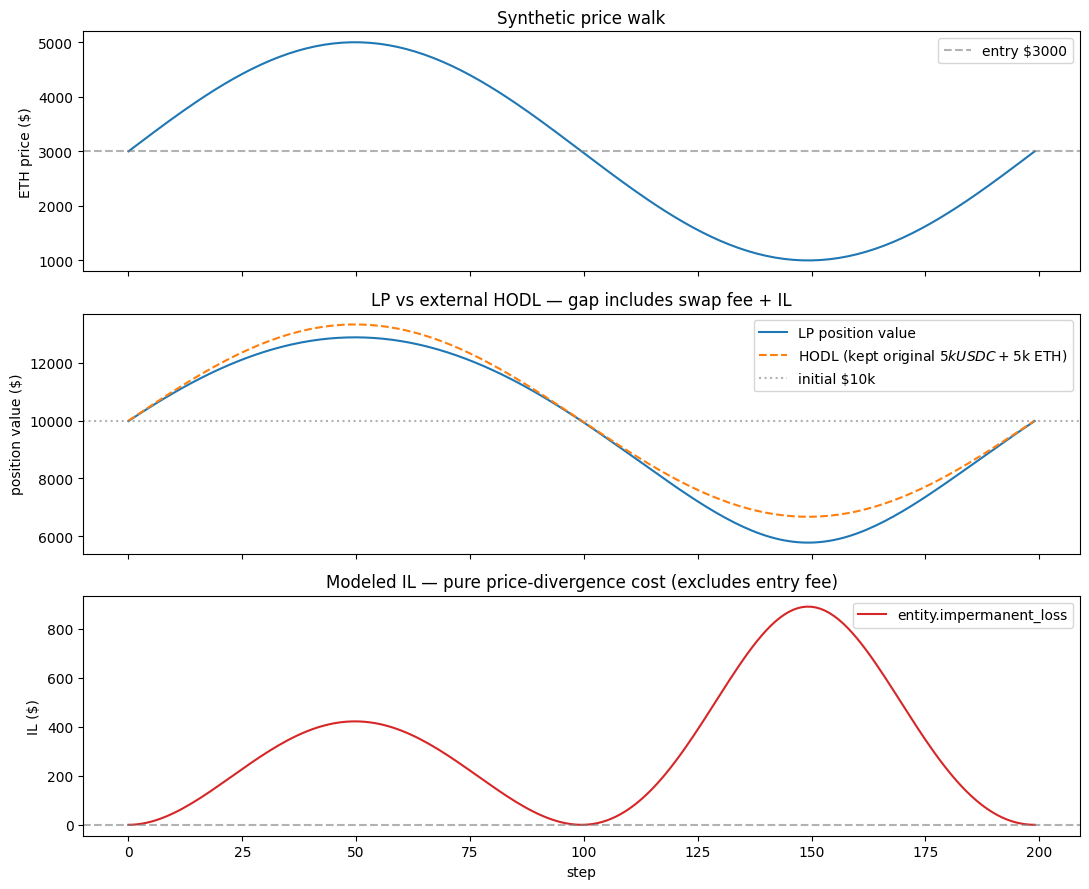

In [20]:
import matplotlib.pyplot as plt

# Three-panel plot: price walk, LP vs HODL values, entity's modeled IL.
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

ax1.plot(price_path, color="tab:blue", linewidth=1.5)
ax1.axhline(entry_price, color="grey", linestyle="--", alpha=0.6,
            label=f"entry ${entry_price:.0f}")
ax1.set(ylabel="ETH price ($)", title="Synthetic price walk")
ax1.legend(loc="upper right")

ax2.plot(lp_values, label="LP position value", linewidth=1.5)
ax2.plot(hodl_values, label="HODL (kept original $5k USDC + $5k ETH)",
         linewidth=1.5, linestyle="--")
ax2.axhline(10_000, color="grey", linestyle=":", alpha=0.6, label="initial $10k")
ax2.set(ylabel="position value ($)",
        title="LP vs external HODL — gap includes swap fee + IL")
ax2.legend(loc="upper right")

ax3.plot(il_values, color="tab:red", linewidth=1.5,
         label="entity.impermanent_loss")
ax3.axhline(0, color="grey", linestyle="--", alpha=0.6)
ax3.set(xlabel="step", ylabel="IL ($)",
        title="Modeled IL — pure price-divergence cost (excludes entry fee)")
ax3.legend(loc="upper right")

plt.tight_layout()
plt.show()

**What you should see:**

- LP position curves with the price (sqrt-shape) but **lags** the HODL
  benchmark whenever price diverges from entry — the famous
  impermanent-loss profile.
- At the very end, when price returns to entry, the LP curve almost
  meets HODL again. The tiny residual is the **swap fee paid on the
  half-deposit at zap-in** (`pool_fee_rate * 0.5 * notional`) — that
  cost is already paid before any price move.
- The entity exposes **two different IL metrics**, and the third panel
  draws the academic one:
  - `lp.balance - external_HODL` (gap on panel 2) =
    swap fee at entry + price-divergence cost
  - `lp.impermanent_loss` (panel 3) = price-divergence cost only,
    measured against the post-fee mint baseline; it returns to zero
    when price returns to entry.

This is the entity behaving as a state-machine model — no strategy,
no observations list, just direct `action_*` + `update_state` calls.
The pool snapshot is kept self-consistent with the price walk via
`tvl = 2 * sqrt(k * price)` (the V2 invariant), otherwise the
rebalancing math inside `update_state` would cancel out and the LP
curve would come out artificially flat.


## 4. Real-data backtest — ETH/USDC V2 pool

Same `UniswapV2LPEntity` as above, but driven by **real on-chain pool
snapshots** + **real ETH price**. We'll do the simplest possible
strategy: deposit $10,000 once, hold the LP for 90 days, observe the
equity curve.

Data sources:

- Pool hourly TVL/volume/fees/liquidity from **TheGraph** Uniswap V2
  subgraph (USDC/WETH 30bps pool, address
  `0xb4e16d0168e52d35cacd2c6185b44281ec28c9dc`)
- ETH price from **Binance** (ETHUSDT spot 1h klines)

Both loaders cache locally (`fractal_data/` directory next to the
notebook), so re-runs are instant.

> **Need a TheGraph API key** for this section — set it as an env var

In [23]:
import os

os.environ['THE_GRAPH_API_KEY'] = ''

In [24]:
from datetime import UTC, datetime
import pandas as pd

from fractal.loaders.base_loader import LoaderType
from fractal.loaders.binance import BinanceHourPriceLoader
from fractal.loaders.thegraph.uniswap_v2 import EthereumUniswapV2PoolDataLoader

api_key = os.getenv("THE_GRAPH_API_KEY")
assert api_key, ("Set THE_GRAPH_API_KEY before launching jupyter — get "
                 "one free at https://thegraph.com/studio/apikeys/")

POOL_ADDRESS = "0xb4e16d0168e52d35cacd2c6185b44281ec28c9dc"  # USDC/WETH 0.3%
START = datetime(2024, 4, 1, tzinfo=UTC)
END = datetime(2024, 7, 1, tzinfo=UTC)

print(f"window: {START.date()} → {END.date()}  ({(END - START).days} days)")

window: 2024-04-01 → 2024-07-01  (91 days)


In [25]:
# Load real pool data + ETH spot price for the same window.
pool_loader = EthereumUniswapV2PoolDataLoader(
    api_key=api_key, pool=POOL_ADDRESS, fee_tier=0.003,
    start_time=START, end_time=END,
    loader_type=LoaderType.CSV,
)
price_loader = BinanceHourPriceLoader(
    ticker="ETHUSDT",
    start_time=START, end_time=END,
    loader_type=LoaderType.CSV,
)

pool_data = pool_loader.read(with_run=True)
price_data = price_loader.read(with_run=True)

print(f"pool snapshots: {len(pool_data)} rows ({list(pool_data.columns)})")
print(f"price points:   {len(price_data)} rows")

pool snapshots: 2184 rows (['tvl', 'volume', 'fees', 'liquidity'])
price points:   2185 rows


In [27]:
# cache reading is faster now
%time
pool_loader.read(with_run=False)

CPU times: user 8 μs, sys: 0 ns, total: 8 μs
Wall time: 46.3 μs


,tvl,volume,fees,liquidity
time,,,,
2024-04-01 00:00:00+00:00,9.377271e+07,333795.069495,1001.385208,0.336624
2024-04-01 01:00:00+00:00,9.366270e+07,309155.794960,927.467385,0.336624
2024-04-01 02:00:00+00:00,9.375178e+07,261173.624643,783.520874,0.336624
2024-04-01 03:00:00+00:00,9.367448e+07,242207.739820,726.623219,0.336610
2024-04-01 04:00:00+00:00,9.365056e+07,306384.497928,919.153494,0.336610
...,...,...,...,...
2024-06-30 19:00:00+00:00,1.025763e+08,134273.283716,402.819851,0.370221
2024-06-30 20:00:00+00:00,1.025970e+08,74209.423483,222.628270,0.370221
2024-06-30 21:00:00+00:00,1.025064e+08,156043.374512,468.130124,0.370221


**Build observations** by joining pool + price on hourly timestamps —
the framework needs one `Observation` per hour with the
`UniswapV2LPGlobalState` populated from both feeds.


In [28]:
def build_v2_observations(pool_data, price_data) -> List[Observation]:
    df = pool_data.join(price_data, how="inner").dropna()
    df = df[df["tvl"] > 0].sort_index()
    return [
        Observation(timestamp=ts, states={
            "POOL": UniswapV2LPGlobalState(
                price=row["price"], tvl=row["tvl"], volume=row["volume"],
                fees=row["fees"], liquidity=row["liquidity"],
            ),
        })
        for ts, row in df.iterrows()
    ]


observations = build_v2_observations(pool_data, price_data)
print(f"observations: {len(observations)}, first: {observations[0].timestamp}")

observations: 2184, first: 2024-04-01 00:00:00+00:00


**Strategy: deposit once, hold.** Same shape as the passive lender —
`set_up` registers a single entity, `predict` returns one
`open_position` action on the first tick and nothing afterwards. The
entity's `update_state` accrues swap fees and tracks pool repricing on
every observation.


In [29]:
@dataclass
class V2HoldParams(BaseStrategyParams):
    INITIAL_BALANCE: float = 10_000.0
    POOL_FEE_RATE: float = 0.003


class V2HoldStrategy(BaseStrategy[V2HoldParams]):
    def set_up(self) -> None:
        self.register_entity(NamedEntity(
            entity_name="POOL",
            entity=UniswapV2LPEntity(config=UniswapV2LPConfig(
                pool_fee_rate=self._params.POOL_FEE_RATE,
                notional_side="token0",  # USDC = token0
            )),
        ))
        self._opened = False

    def predict(self) -> List[ActionToTake]:
        if self._opened:
            return []
        self._opened = True
        # Two-step: deposit cash into the entity, then deploy as LP.
        return [
            ActionToTake("POOL", Action(
                "deposit", {"amount_in_notional": self._params.INITIAL_BALANCE},
            )),
            ActionToTake("POOL", Action(
                "open_position", {"amount_in_notional": self._params.INITIAL_BALANCE},
            )),
        ]


strategy = V2HoldStrategy(params=V2HoldParams())
result = strategy.run(observations)
result.get_default_metrics()

StrategyMetrics(accumulated_return=np.float64(0.019701288276740003), apy=np.float64(0.07905784942933688), sharpe=np.float64(0.4120965160150329), max_drawdown=-0.10958505666694707)

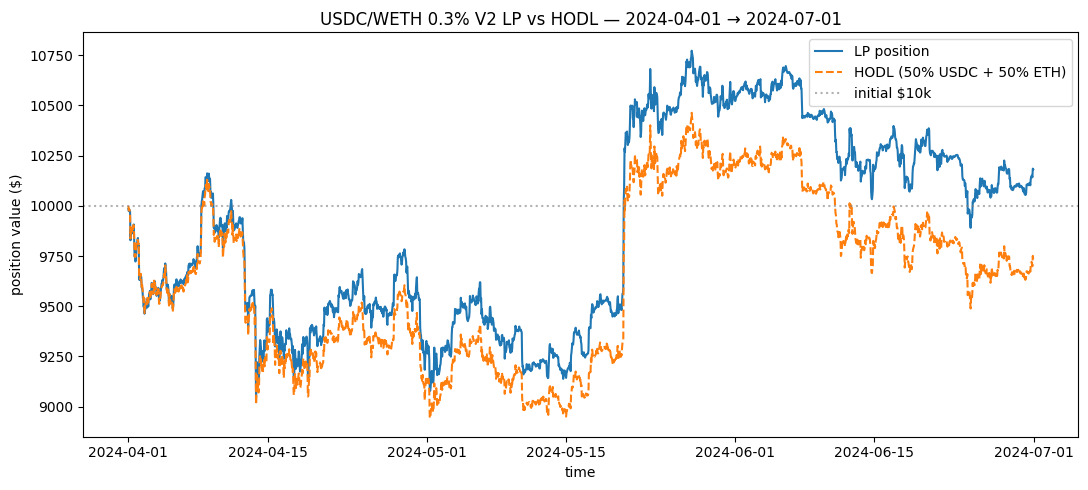

LP final:   $10,181.72  (+1.82%)
HODL final: $9,733.96  (-2.66%)
LP edge over HODL: +4.48%  (+ = fees paid back the IL, - = IL won)


In [30]:
# Compare LP equity curve to a HODL baseline (50% USDC + 50% ETH at entry).
df_run = result.to_dataframe()

entry_px = observations[0].states["POOL"].price
hodl_eth = 5_000.0 / entry_px
hodl_curve = 5_000.0 + hodl_eth * df_run["POOL_price"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_run["timestamp"], df_run["net_balance"], label="LP position", linewidth=1.5)
ax.plot(df_run["timestamp"], hodl_curve, label="HODL (50% USDC + 50% ETH)",
        linewidth=1.5, linestyle="--")
ax.axhline(10_000, color="grey", linestyle=":", alpha=0.6, label="initial $10k")
ax.set(title=f"USDC/WETH 0.3% V2 LP vs HODL — {START.date()} → {END.date()}",
       xlabel="time", ylabel="position value ($)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

final_lp = float(df_run["net_balance"].iloc[-1])
final_hodl = float(hodl_curve.iloc[-1])
print(f"LP final:   ${final_lp:,.2f}  ({final_lp/10_000 - 1:+.2%})")
print(f"HODL final: ${final_hodl:,.2f}  ({final_hodl/10_000 - 1:+.2%})")
print(f"LP edge over HODL: {(final_lp - final_hodl) / 10_000:+.2%}  "
      "(+ = fees paid back the IL, - = IL won)")

## 5. Where to go next

| Repository path | What's there |
|---|---|
| [`examples/basis/`](../basis/) | Hyperliquid basis trade — perp-short hedged spot-long |
| [`examples/tau_reset/`](../tau_reset/) | Active V3 LP with τ-reset rebalancing |
| [`examples/tau_reset/grid.py`](../tau_reset/grid.py) | Same strategy under a hyperparam grid + MLflow logging |
| [`examples/holder/`](../holder/) | Toy spot HODL with simple buy/sell triggers |
| [`examples/agentic_trader/`](../agentic_trader/) | LLM-driven trading agent over historical klines |

**MLflow tracking** for grid runs:

```bash
export MLFLOW_URI=http://localhost:5500
python examples/tau_reset/grid.py
```

**Architecture deep-dive** (entity contracts, IS/GS split,
delegate-resolved actions, notional accounting):
[`ARCHITECTURE.md`](../../ARCHITECTURE.md).

Questions / contributions: open an issue from one of the templates at
[github.com/Logarithm-Labs/fractal-defi/issues](https://github.com/Logarithm-Labs/fractal-defi/issues).
